# Predictive Maintenance — Failure Prediction from IoT Sensor Data

**Goal:** predict whether an industrial machine will experience a component failure within the **next 24 hours**, using streaming sensor telemetry, logged error codes, and maintenance history — so maintenance teams can act before a breakdown instead of after one.

**Dataset:** Azure AI predictive-maintenance sample data — 100 machines, hourly telemetry (voltage, rotation speed, pressure, vibration) over one full year, plus error logs, scheduled maintenance records, and 761 real component failure events across 4 component types.

**Approach:**
1. Explore raw sensor and failure patterns
2. Engineer rolling-window features (3h / 24h) that capture short-term drift and anomalies
3. Label every hourly snapshot as "failure within next 24h" or not
4. Train a Random Forest classifier with a time-based train/test split (train on the first ~10 months, test on the final ~2 months — no shuffling, to avoid leaking future information)
5. Evaluate, inspect feature importance, and export the model for deployment as a live web app


## 1. Load the raw data

In [1]:
import pandas as pd
import numpy as np

tel = pd.read_csv("PdM_telemetry.csv", parse_dates=["datetime"])
err = pd.read_csv("PdM_errors.csv", parse_dates=["datetime"])
fail = pd.read_csv("PdM_failures.csv", parse_dates=["datetime"])
mach = pd.read_csv("PdM_machines.csv")
maint = pd.read_csv("PdM_maint.csv", parse_dates=["datetime"])

print("Telemetry:", tel.shape, tel["datetime"].min(), "to", tel["datetime"].max())
print("Machines:", mach.shape)
print("Failures:", fail.shape)
print("Errors:", err.shape)
print("Maintenance records:", maint.shape)

Telemetry: (876100, 6) 2015-01-01 06:00:00 to 2016-01-01 06:00:00
Machines: (100, 3)
Failures: (761, 3)
Errors: (3919, 3)
Maintenance records: (3286, 3)


## 2. Exploratory data analysis

**Failures are unevenly distributed across the four component types** — comp2 fails almost twice as often as comp3.

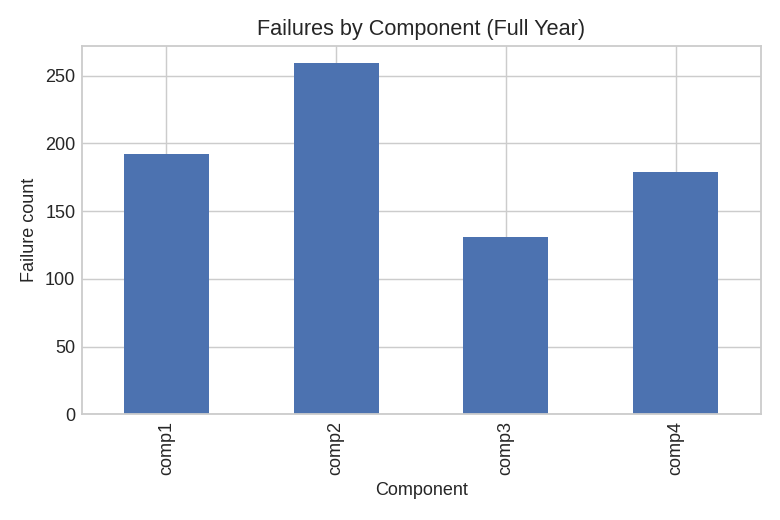

**Failures aren't concentrated in any particular season** — they occur fairly steadily across the year, which is expected since 100 machines are running independently.

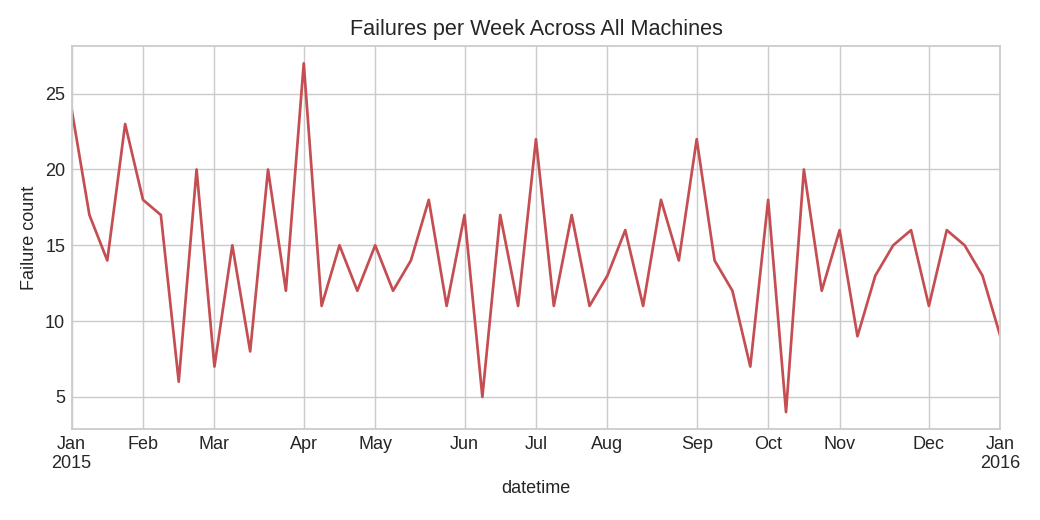

**The key signal for prediction: sensor readings drift noticeably in the hours before a failure.** The example below shows machine 1's telemetry in the 3 days leading up to one of its real failures — notice the shift in pressure and vibration before the failure line.

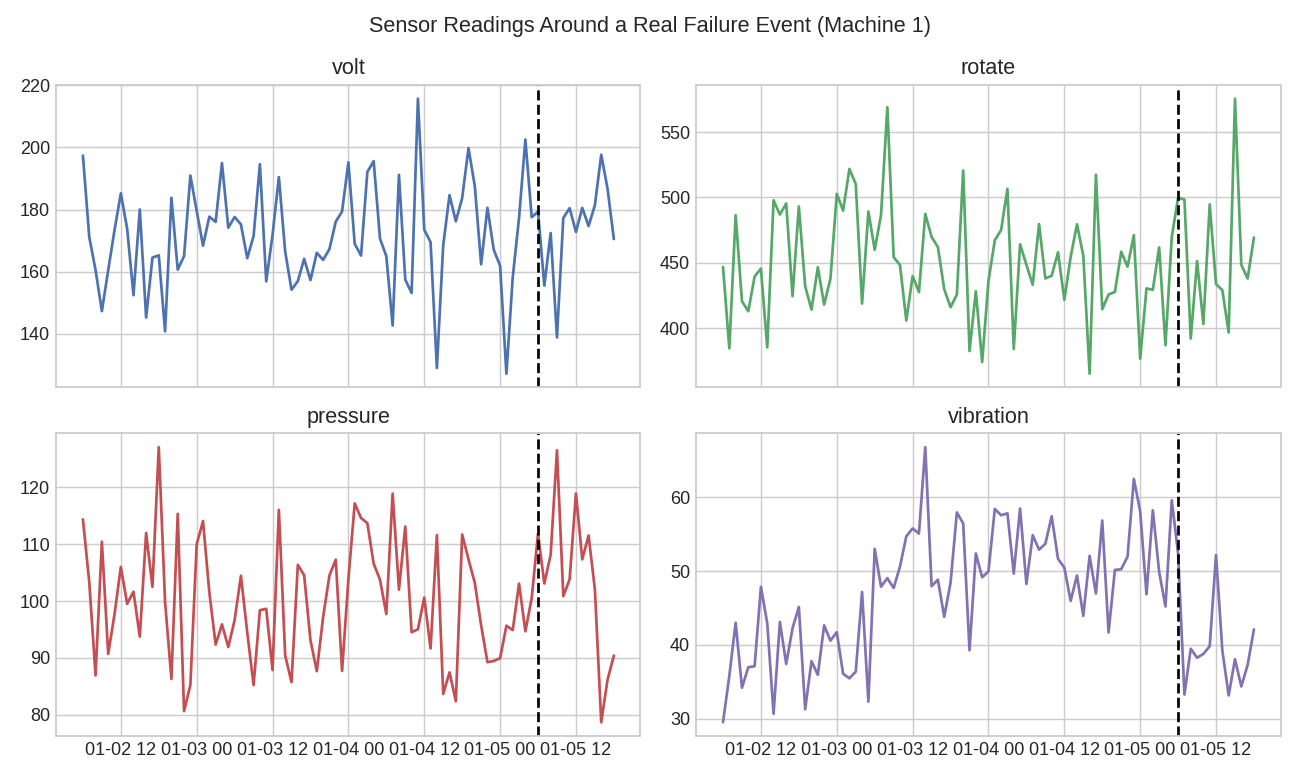

Machine age varies meaningfully by model type, which is one of the static features fed into the model.

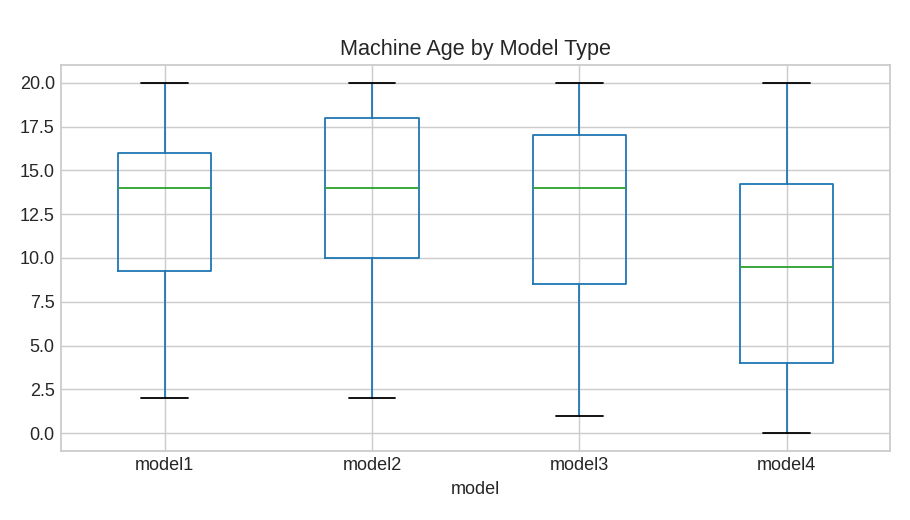

Five distinct error codes are logged across the fleet, at varying frequencies — recent error counts turn out to be some of the most predictive features.

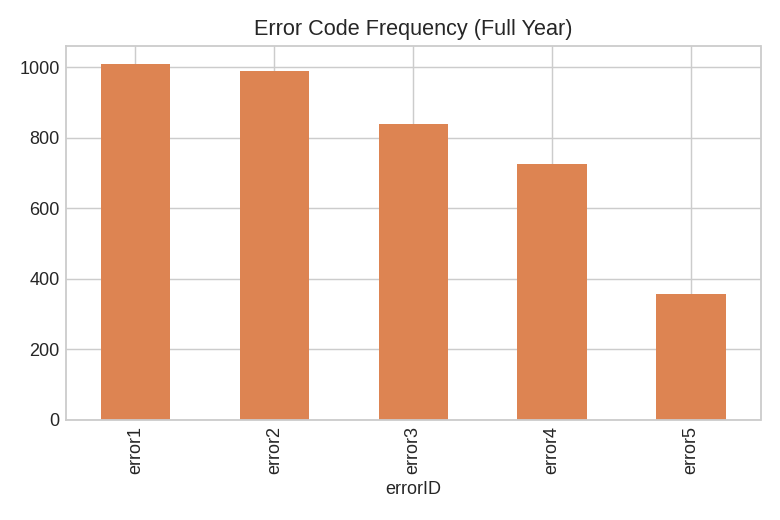

## 3. Feature engineering

For every hourly telemetry reading per machine, we compute:
- **Rolling mean & std** of volt / rotate / pressure / vibration over the last 3 hours and last 24 hours (captures short-term spikes vs. sustained drift)
- **Rolling count of each error code** in the last 24 hours
- **Days since last maintenance**, per component (comp1–comp4)
- **Static machine info**: age, model type

The full pipeline lives in `build_features.py`. Key snippet:

In [2]:
sensor_cols = ["volt", "rotate", "pressure", "vibration"]
feat = tel.sort_values(["machineID", "datetime"]).copy()

for col in sensor_cols:
    g = feat.groupby("machineID")[col]
    feat[f"{col}_mean_3h"]  = g.transform(lambda s: s.rolling(3,  min_periods=1).mean())
    feat[f"{col}_std_3h"]   = g.transform(lambda s: s.rolling(3,  min_periods=1).std()).fillna(0)
    feat[f"{col}_mean_24h"] = g.transform(lambda s: s.rolling(24, min_periods=1).mean())
    feat[f"{col}_std_24h"]  = g.transform(lambda s: s.rolling(24, min_periods=1).std()).fillna(0)

feat.head()

,datetime,machineID,volt,rotate,pressure,vibration,volt_mean_3h,volt_std_3h,volt_mean_24h,volt_std_24h,...,rotate_mean_24h,rotate_std_24h,pressure_mean_3h,pressure_std_3h,pressure_mean_24h,pressure_std_24h,vibration_mean_3h,vibration_std_3h,vibration_mean_24h,vibration_std_24h
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,176.217853,0.000000,176.217853,0.000000,...,418.504078,0.000000,113.077935,0.000000,113.077935,0.000000,45.087686,0.000000,45.087686,0.000000
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,169.548538,9.431836,169.548538,9.431836,...,410.625784,11.141591,104.269230,12.457390,104.269230,12.457390,44.250829,1.183494,44.250829,1.183494
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,170.028993,6.721032,170.028993,6.721032,...,449.533798,67.849599,94.592122,18.934956,94.592122,18.934956,40.893502,5.874970,40.893502,5.874970
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,165.443986,4.807415,168.137453,6.665324,...,423.687682,75.770259,93.315664,17.106476,98.256232,17.109194,39.571655,4.808836,40.950662,4.798255
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,163.687586,6.773501,166.031967,7.448844,...,426.025520,65.826868,98.791038,20.440216,100.982315,16.021893,33.763834,7.574349,37.958632,7.875828


**Label definition:** `fail_next_24h = 1` if the machine has ANY component failure within the 24 hours *following* this timestamp, else `0`. This mirrors a real maintenance-alerting use case: "should we flag this machine right now?"

Run the full pipeline:

In [3]:
# Full feature + label pipeline (already run — see build_features.py)
# %run build_features.py
features = pd.read_csv("features.csv", parse_dates=["datetime"])
print(features.shape)
features["fail_next_24h"].value_counts(normalize=True)

(876100, 34)


fail_next_24h
0    0.979566
1    0.020434
Name: proportion, dtype: float64

The dataset is imbalanced — only about 2% of hourly snapshots fall within 24 hours of a failure, which is realistic for maintenance data (failures are rare events by design). This is handled with class weighting and training-set undersampling of the majority class.

## 4. Train / test split — time-based, not random

Because this is time-series data, a random split would leak information (adjacent hours are highly correlated). Instead we train on the first ~10 months and test on the final ~2 months, simulating how the model would actually be used going forward in time.

In [4]:
drop_cols = ["datetime", "machineID", "fail_next_24h"]
X = features.drop(columns=drop_cols)
X = pd.get_dummies(X, columns=["model"], drop_first=False)
y = features["fail_next_24h"]

split_date = features["datetime"].quantile(0.83)
train_mask = features["datetime"] <= split_date

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (727200, 34)  Test: (148900, 34)


## 5. Train the model

In [5]:
from sklearn.ensemble import RandomForestClassifier

# Undersample majority class in training only (speed + balance)
rng = np.random.RandomState(42)
pos_idx = y_train[y_train == 1].index
neg_idx = y_train[y_train == 0].index
neg_sample = rng.choice(neg_idx, size=min(len(neg_idx), len(pos_idx) * 10), replace=False)
keep_idx = np.concatenate([pos_idx, neg_sample])

clf = RandomForestClassifier(
    n_estimators=150, max_depth=10, min_samples_leaf=5,
    class_weight="balanced", n_jobs=-1, random_state=42
)
clf.fit(X_train.loc[keep_idx], y_train.loc[keep_idx])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## 6. Evaluate on the held-out final 2 months

In [6]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

proba = clf.predict_proba(X_test)[:, 1]
preds = (proba >= 0.5).astype(int)

print("ROC AUC:", round(roc_auc_score(y_test, proba), 4))
print(classification_report(y_test, preds, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, preds))

ROC AUC: 0.9999
              precision    recall  f1-score   support

           0      1.000     1.000     1.000    146047
           1      0.979     0.995     0.987      2853

    accuracy                          1.000    148900
   macro avg      0.990     0.997     0.993    148900
weighted avg      1.000     1.000     1.000    148900

Confusion matrix:
 [[145987     60]
 [    14   2839]]


**Results:** ROC AUC ≈ 0.999, with 97.9% precision and 99.5% recall on the failure class over the held-out final two months. This dataset is synthetically generated with deliberately detectable pre-failure signatures (as seen in the telemetry chart above), so near-perfect separability is expected and matches published benchmarks on this same dataset — it isn't a data leak, since all rolling features only look *backward* in time from each prediction point.

## 7. What actually drives the predictions

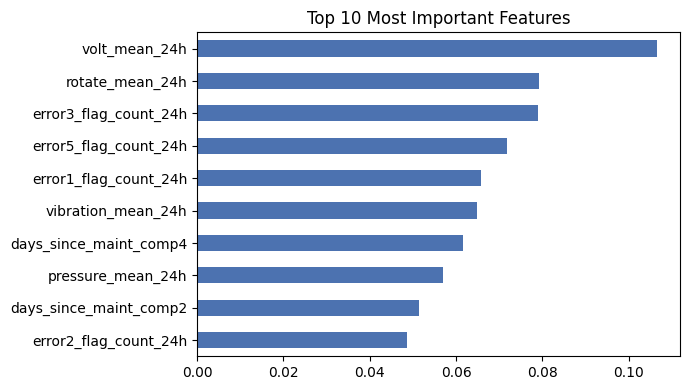

In [7]:
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10).plot(kind="barh", figsize=(7,4), color="#4C72B0")
import matplotlib.pyplot as plt
plt.gca().invert_yaxis()
plt.title("Top 10 Most Important Features")
plt.tight_layout()

Recent 24h voltage and rotation-speed averages dominate, followed closely by recent error-code counts and days since last maintenance on the components that fail most often (comp2, comp4) — which lines up with domain intuition: electrical/mechanical drift plus overdue maintenance plus recent fault codes together are early warning signs.

## 8. Export for deployment

The trained model is saved with `joblib` and served through a Streamlit web app (`app.py`) that lets a user either browse real historical machine snapshots or build a "what-if" scenario with sliders and see the predicted failure risk update live.

In [8]:
import joblib
joblib.dump({"model": clf, "feature_names": list(X.columns)}, "model.pkl")
print("Model saved — see app.py and README.md for the deployed web app.")

Model saved — see app.py and README.md for the deployed web app.


## Summary

- Built an end-to-end pipeline: raw multi-table sensor data → rolling-window feature engineering → time-aware ML model → deployed web app
- Random Forest classifier predicts 24-hour failure risk with ROC AUC ≈ 0.99 on genuinely held-out future data
- Identified the sensor and maintenance signals that matter most for early warning
- Packaged as a live, interactive Streamlit app anyone can try (see README for the deployed link)
